In [11]:
import pandas as pd
import numpy as np

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt

In [16]:
from google.colab import files
uploaded = files.upload()


Saving iris.csv to iris.csv


In [18]:
df = pd.read_csv('iris.csv')

In [29]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [32]:
X = df.drop('species', axis=1)
y = df['species']

In [33]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
model = Sequential()

In [37]:
model.add(Dense(8, activation='relu', input_shape=(4,)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.add(Dense(3, activation='softmax'))

In [39]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_test, y_test)
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.3167 - loss: 1.3908 - val_accuracy: 0.3000 - val_loss: 1.4978
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3167 - loss: 1.3656 - val_accuracy: 0.3000 - val_loss: 1.4674
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3167 - loss: 1.3419 - val_accuracy: 0.3000 - val_loss: 1.4370
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3083 - loss: 1.3167 - val_accuracy: 0.3000 - val_loss: 1.4075
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3250 - loss: 1.2934 - val_accuracy: 0.3000 - val_loss: 1.3786
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3333 - loss: 1.2681 - val_accuracy: 0.3667 - val_loss: 1.3508
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3333 - loss: 1.2470 - val_accuracy: 0.3667 - val_loss: 1.3226
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3667 - loss: 1.2232 - val_accuracy: 0.4333 - val_loss

In [41]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9333 - loss: 0.3208
Accuracy: 0.9333333373069763


In [42]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
[1 0 2 2 1 0 1 2 1 1 2 0 0 0 0 2 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [43]:
print("Prediksi :", predicted_classes[:10])
print("Asli      :", y_test[:10])

Prediksi : [1 0 2 2 1 0 1 2 1 1]
Asli      : [1 0 2 1 1 0 1 2 1 1]


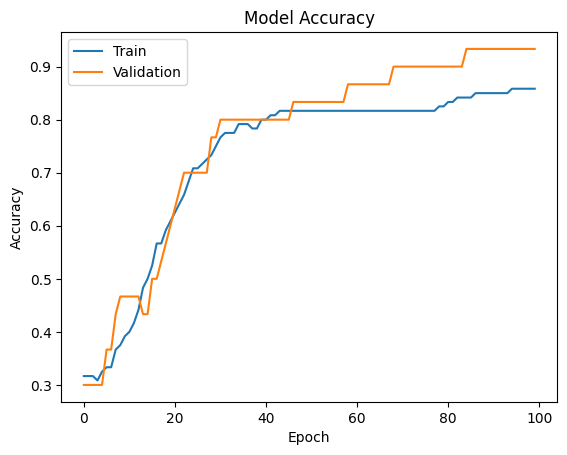

In [44]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()